<a href="https://colab.research.google.com/github/crystalloide/Big_Data/blob/master/Pr%C3%A9diction_de_Commandes_dans_les_30_Jours_%20version_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Prédiction de Commandes dans les 30 Jours
•	Contexte et Objectif
Vous travaillez en tant qu'analyste data pour une société de e-commerce.
Vous disposez d'un jeu de données appelé clients.csv, contenant des informations sur les clients et leurs habitudes d'achat.
L'entreprise souhaite prédire la probabilité qu'un client passe une commande dans les 30 jours suivant sa dernière visite, afin d'optimiser ses campagnes marketing et de personnaliser son engagement client.

-	Enjeux Métier

-	Minimiser les faux négatifs : ne pas identifier un client susceptible de commander entraîne une perte de chiffre d'affaires

-	Équilibrer recall et précision : trop d'alertes inutiles surcharge l'équipe marketing

-	Interprétabilité : comprendre quels facteurs prédisent un achat est crucial pour les décisions métier
________________________________________
-	Variables Disponibles

| Variable | Type | Description |
|----------|------|-------------|
| `age` | Numérique | Âge du client |
| `sexe` | Catégorique | Sexe du client |
| `revenu_mensuel` | Numérique | Revenu mensuel estimé |
| `nbr_visites_30j` | Numérique | Nombre de visites dans les 30 derniers jours |
| `temps_depuis_derniere_commande` | Numérique | Jours écoulés depuis la dernière commande |
| `type_client` | Catégorique | Classification : occasionnel, fidèle, premium |
| `commande_30j` | Binaire | Variable cible (0 = non, 1 = oui) |


•	Étape 1 – Chargement et Exploration des Données

•	Objectif :
Comprendre la structure des données, vérifier leur qualité, identifier des anomalies ou déséquilibres.


Forme du jeu de données : (1900, 7)

Premières lignes :
    age sexe  revenu_mensuel  nbr_visites_30j  temps_depuis_derniere_commande  \
0    56    F     3214.425649                4                      111.683983   
1    69    F     1970.479347                5                       22.091261   
2    46    M     1013.519344                5                       31.499041   
3    32    M     5420.762039                3                       17.945031   
4    60    F      231.077218                7                       48.923575   
5    25    M     1498.018114                3                      238.706188   
6    38    F     1021.218894                0                        1.163010   
8    36    F     2065.267269                6                        0.177020   
9    40    F     1854.803542                4                       20.381179   
10   28    M     7114.275228                5                        8.309360   

    type_client  commande_30j  
0   occasionnel     

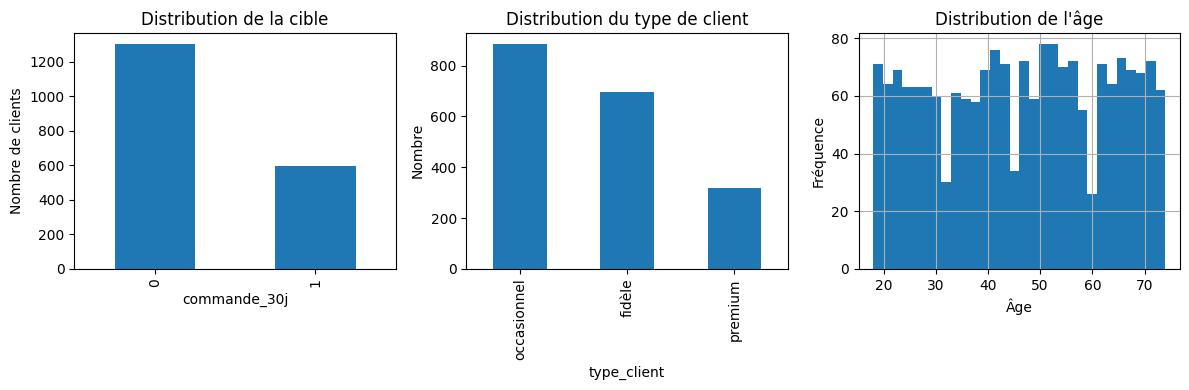

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement
df_brut = pd.read_csv('clients.csv')
# On supprimer les NaN
df = df_brut.dropna()

# Vue d'ensemble
print("Forme du jeu de données :", df.shape)
print("\nPremières lignes :")
print(df.head(10))

print("\nTypes de données :")
print(df.dtypes)

print("\nStatistiques descriptives :")
print(df.describe())

# Vérification des valeurs manquantes
print("\nValeurs manquantes :")
print(df.isnull().sum())

# Distribution de la variable cible
print("\nDistribution de la cible (commande_30j) :")
distribution = df['commande_30j'].value_counts(normalize=True)
print(distribution)
print(f"Déséquilibre : {distribution.iloc[0]:.1%} vs {distribution.iloc[1]:.1%}")

# Visualisation
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
df['commande_30j'].value_counts().plot(kind='bar')
plt.title("Distribution de la cible")
plt.ylabel("Nombre de clients")

plt.subplot(1, 3, 2)
df['type_client'].value_counts().plot(kind='bar')
plt.title("Distribution du type de client")
plt.ylabel("Nombre")

plt.subplot(1, 3, 3)
df['age'].hist(bins=30)
plt.title("Distribution de l'âge")
plt.xlabel("Âge")
plt.ylabel("Fréquence")

plt.tight_layout()
plt.show()


•	Points Clés à Vérifier

•	Déséquilibre des classes : Si la cible est très déséquilibrée (ex: 90% de 0), envisager une stratification ou un rééquilibrage

•	Valeurs manquantes : Stratégie d'imputation si nécessaire (ici on a supprimé)

•	Outliers : Détecter des anomalies dans revenu_mensuel ou temps_depuis_derniere_commande

•	Corrélations : Identifier les variables les plus liées à la cible


•	Étape 2 – Analyse Exploratoire et Sélection des Variables

•	Objectif :
Identifier les variables explicatives pertinentes et vérifier les hypothèses.


Corrélations avec la cible (commande_30j) :
commande_30j                      1.000000
revenu_mensuel                    0.141172
nbr_visites_30j                   0.057682
age                               0.005771
temps_depuis_derniere_commande   -0.098688
Name: commande_30j, dtype: float64

Proportion de commandes par type_client :
             sum  count      mean
type_client                      
fidèle       255    696  0.366379
occasionnel  182    885  0.205650
premium      161    319  0.504702


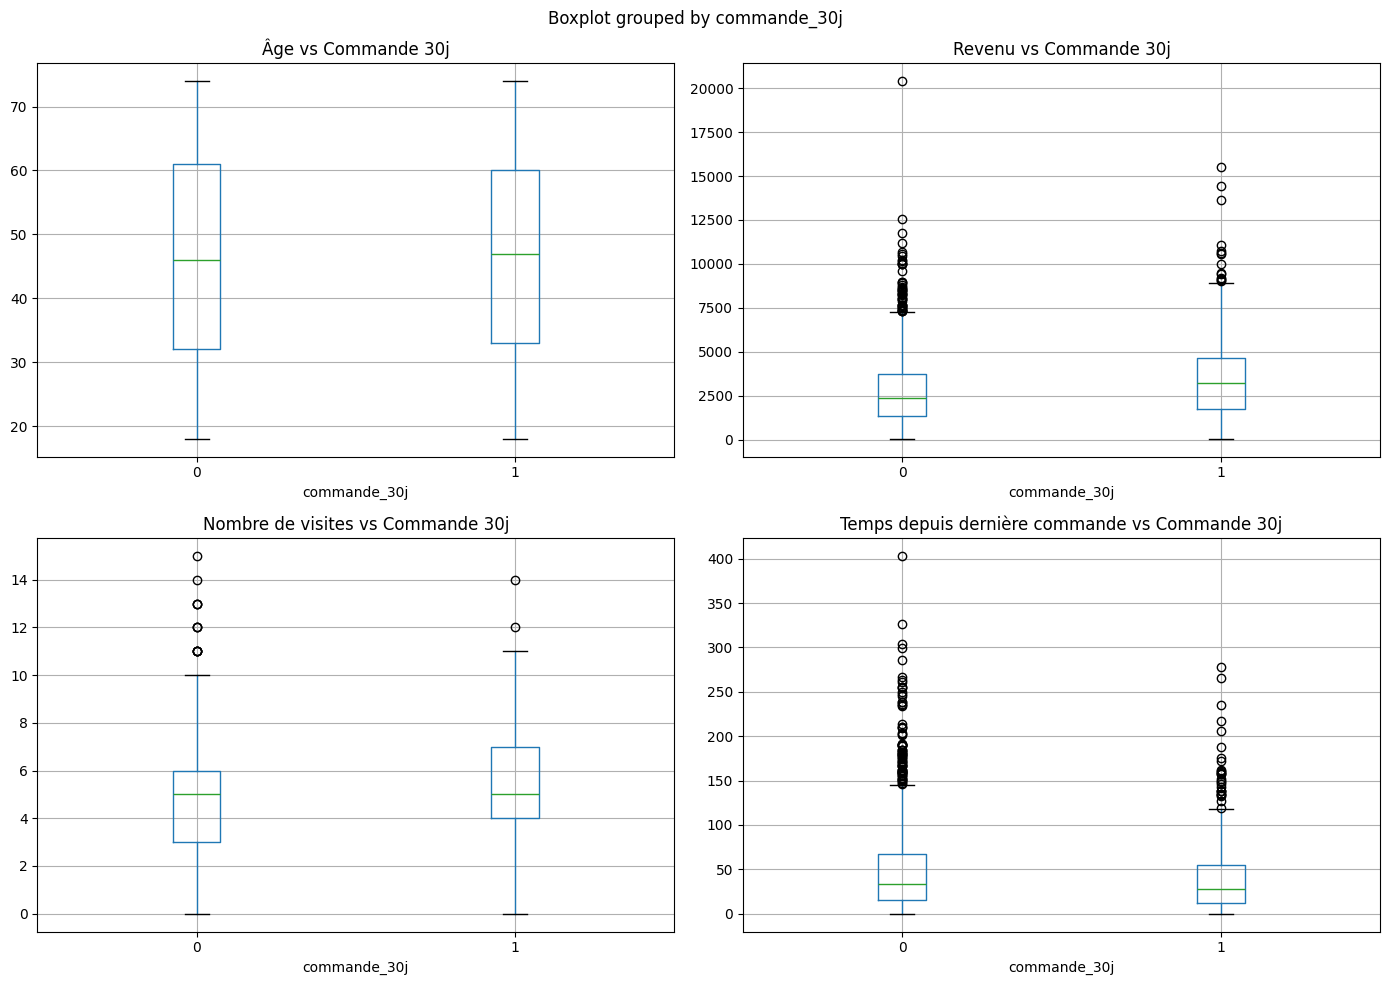

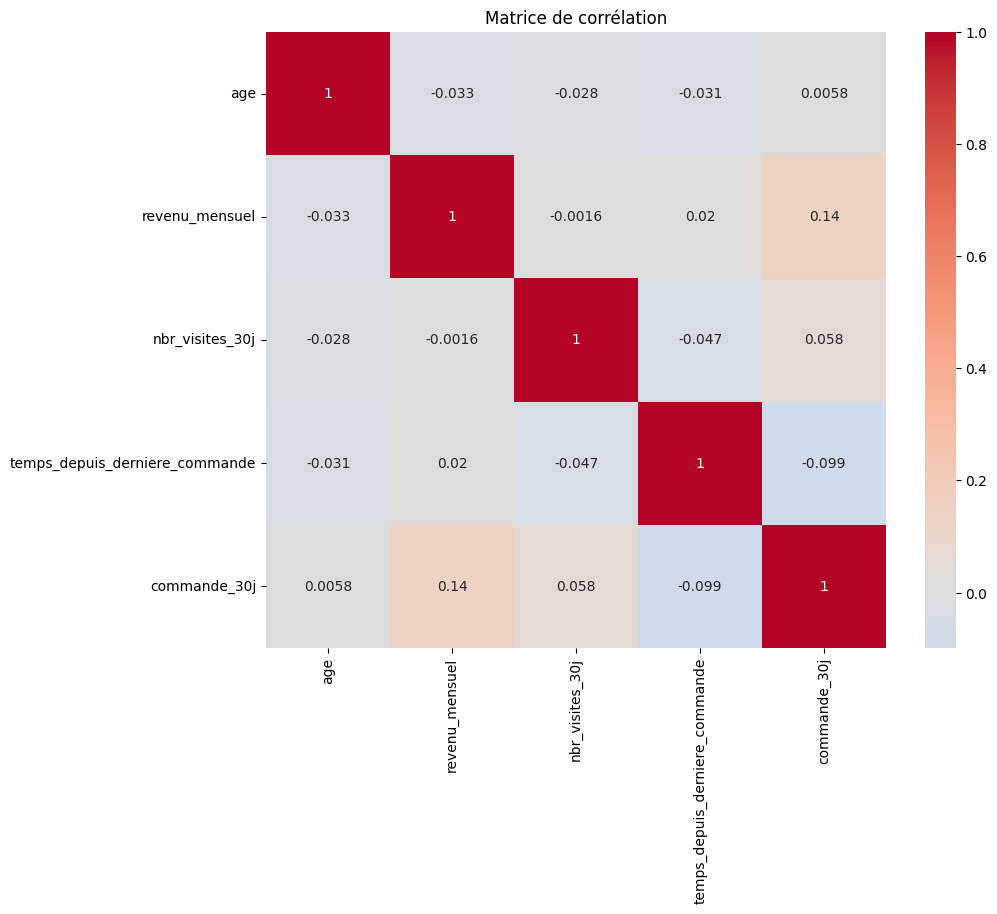

In [ ]:
# Corrélations avec la cible
print("Corrélations avec la cible (commande_30j) :")
print(df[['age', 'revenu_mensuel', 'nbr_visites_30j', 'temps_depuis_derniere_commande', 'commande_30j']].corr()['commande_30j'].sort_values(ascending=False))

# Analyse bivariée par type de client
print("\nProportion de commandes par type_client :")
print(df.groupby('type_client')['commande_30j'].agg(['sum', 'count', 'mean']))

# Visualisation
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribution by target
df.boxplot(column='age', by='commande_30j', ax=axes[0, 0])
axes[0, 0].set_title("Âge vs Commande 30j")

df.boxplot(column='revenu_mensuel', by='commande_30j', ax=axes[0, 1])
axes[0, 1].set_title("Revenu vs Commande 30j")

df.boxplot(column='nbr_visites_30j', by='commande_30j', ax=axes[1, 0])
axes[1, 0].set_title("Nombre de visites vs Commande 30j")

df.boxplot(column='temps_depuis_derniere_commande', by='commande_30j', ax=axes[1, 1])
axes[1, 1].set_title("Temps depuis dernière commande vs Commande 30j")

plt.tight_layout()
plt.show()

# Heatmap de corrélation
plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=[np.number]).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0)
plt.title("Matrice de corrélation")
plt.show()


## Sélection des Variables

### Variables conservées :

•	age, revenu_mensuel, nbr_visites_30j, temps_depuis_derniere_commande

•	type_client (à encoder)

•	Optionnel : sexe si corrélé avec la cible

### Variables non utilisées :

•	sexe peut être inclus si données disponibles et pertinent

•	Vérifier la multicolinéarité (VIF > 5 suggère un problème)


•	Étape 3 – Prétraitement et Encodage

•	Objectif :
Préparer les données pour les modèles de machine learning.


In [ ]:
from sklearn.preprocessing import StandardScaler

# Copie de travail
df_processed = df.copy()

# Encodage des variables catégoques
# df_processed = pd.get_dummies(df_processed, columns=['type_client'], drop_first=True)
df_processed = pd.get_dummies(df, columns=['sexe', 'type_client'], drop_first=True)

# Optionnel : encodage de sexe si pertinent
#df_processed['sexe'] = df_processed['sexe'].map({'M': 1, 'F': 0})

print("Colonnes après encodage :")
print(df_processed.columns.tolist())

print("\nAperçu des données encodées :")
print(df_processed.head())

# Séparation X et y
X = df_processed.drop(columns=['commande_30j'])
y = df_processed['commande_30j']

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")

Colonnes après encodage :
['age', 'revenu_mensuel', 'nbr_visites_30j', 'temps_depuis_derniere_commande', 'commande_30j', 'sexe_M', 'type_client_occasionnel', 'type_client_premium']

Aperçu des données encodées :
   age  revenu_mensuel  nbr_visites_30j  temps_depuis_derniere_commande  \
0   56     3214.425649                4                      111.683983   
1   69     1970.479347                5                       22.091261   
2   46     1013.519344                5                       31.499041   
3   32     5420.762039                3                       17.945031   
4   60      231.077218                7                       48.923575   

   commande_30j  sexe_M  type_client_occasionnel  type_client_premium  
0             0   False                     True                False  
1             0   False                     True                False  
2             0    True                    False                 True  
3             0    True                    False 

•	Considérations

•	Normalisation : Les modèles de classification ne l'exigent pas, mais elle peut aider pour la régression logistique

•	Drop first : Éviter la multicolinéarité parfaite

•	Vérifier le déséquilibre : Avant/après encodage


•	Étape 4 – Division Train/Test avec Stratification

•	Objectif :
Créer des ensembles d'entraînement et test représentatifs, surtout si classes déséquilibrées.


In [ ]:
from sklearn.model_selection import train_test_split

# Stratification pour respecter la distribution de la cible
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y  # Important si déséquilibre
)

print(f"Train set : {X_train.shape[0]} samples ({y_train.value_counts(normalize=True).iloc[1]:.1%} positifs)")
print(f"Test set : {X_test.shape[0]} samples ({y_test.value_counts(normalize=True).iloc[1]:.1%} positifs)")


Train set : 1330 samples (31.5% positifs)
Test set : 570 samples (31.4% positifs)


##	Améliorations :

•	Stratification : Garantit la même distribution de classes dans train et test

•	Random state : Reproductibilité

•	Pourcentage 70/30 : Adapté pour la plupart des cas (ajuster si petit jeu de données)


##	Étape 5 – Entraînement des Modèles

•	5.1 Régression Logistique


In [ ]:
from sklearn.linear_model import LogisticRegression
# Vérifier combien de lignes ont des NaN
rows_with_nan = X_train.isna().any(axis=1).sum()
print(f"Lignes avec NaN : {rows_with_nan} / {len(X_train)} ({rows_with_nan/len(X_train)*100:.2f}%)")

# Si < 5%, on peut les supprimer
if rows_with_nan / len(X_train) < 0.05:
    # Supprimer les lignes avec NaN
    mask = ~X_train.isna().any(axis=1)
    X_train_clean = X_train[mask]
    y_train_clean = y_train[mask]

    # De même pour le test
    mask_test = ~X_test.isna().any(axis=1)
    X_test_clean = X_test[mask_test]
    y_test_clean = y_test[mask_test]

    # Entraîner le modèle
    log_model = LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight='balanced'
    )

    log_model.fit(X_train_clean, y_train_clean)
    print("✅ Modèle entraîné sur données nettoyées")
    print(f"Coefficients :\n{pd.Series(log_model.coef_[0], index=X_train.columns).sort_values(ascending=False)}")


else:
    print("⚠️ Trop de lignes avec NaN, utilisez l'imputation plutôt")



Lignes avec NaN : 0 / 1330 (0.00%)
✅ Modèle entraîné sur données nettoyées
Coefficients :
type_client_premium               0.615252
nbr_visites_30j                   0.052691
revenu_mensuel                    0.000115
age                              -0.000536
temps_depuis_derniere_commande   -0.005116
sexe_M                           -0.048948
type_client_occasionnel          -0.835768
dtype: float64


•	5.2 Random Forest

Random Forest entraîné

Importance des features :
revenu_mensuel                    0.266535
temps_depuis_derniere_commande    0.242198
age                               0.183123
type_client_occasionnel           0.120119
nbr_visites_30j                   0.106213
type_client_premium               0.054751
sexe_M                            0.027062
dtype: float64


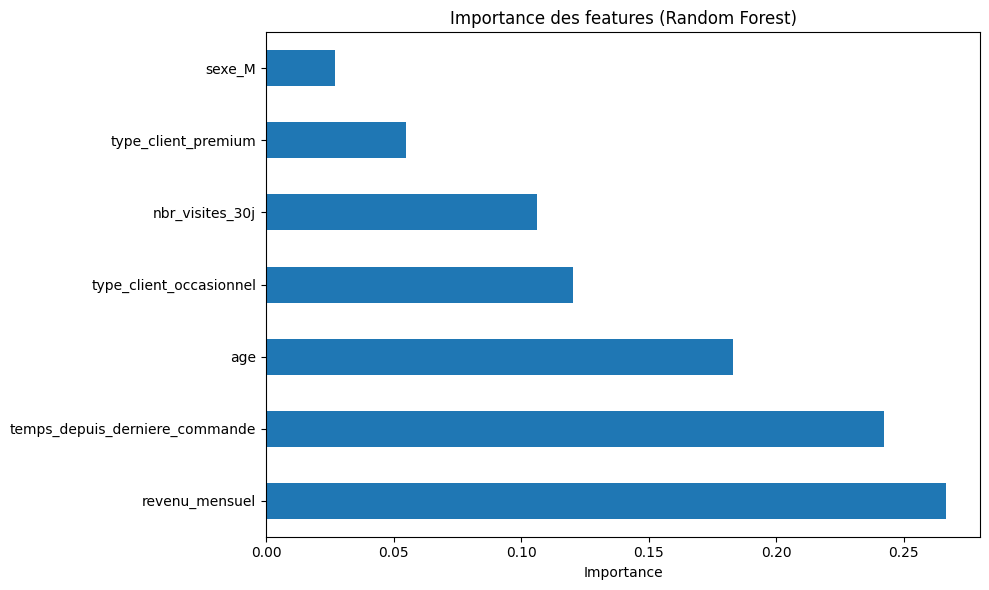

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1  # Parallélisation
)

rf_model.fit(X_train, y_train)

print("Random Forest entraîné")

# Importance des features
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(f"\nImportance des features :\n{feature_importance}")

plt.figure(figsize=(10, 6))
feature_importance.plot(kind='barh')
plt.title("Importance des features (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


## Paramètres clés :

•	class_weight='balanced' : Compense les classes déséquilibrées

•	max_depth : Limite la profondeur pour éviter l'overfitting

•	n_estimators : Nombre d'arbres (100-500 généralement)


## Étape 6 – Évaluation des Modèles

•	Objectif :
Comparer les performances des deux modèles sur le jeu de test avec des métriques adaptées au problème.


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

# Vérifier le nombre de lignes concernées
print(f"Lignes avec NaN dans X_test : {X_test.isnull().any(axis=1).sum()}")

# Si c'est acceptable, supprimer ces lignes
mask_test = ~X_test.isnull().any(axis=1)
X_test_clean = X_test[mask_test]
y_test_clean = y_test[mask_test]


# Prédictions sur données nettoyées
y_pred_log = log_model.predict(X_test_clean)
y_pred_proba_log = log_model.predict_proba(X_test_clean)[:, 1]

y_pred_rf = rf_model.predict(X_test_clean)
y_pred_proba_rf = rf_model.predict_proba(X_test_clean)[:, 1]


# Fonction helper pour l'évaluation
def evaluate_model(y_true, y_pred, y_proba, model_name):
    print(f"\n{'='*50}")
    print(f"Évaluation : {model_name}")
    print(f"{'='*50}")

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_proba)

    print(f"Accuracy  : {accuracy:.4f}  (Proportion globale de bonnes prédictions)")
    print(f"Precision : {precision:.4f}  (Parmi les prédictions positives, % correctes)")
    print(f"Recall    : {recall:.4f}  (Parmi les vrais positifs, % identifiés)")
    print(f"F1-Score  : {f1:.4f}  (Moyenne harmonique de precision et recall)")
    print(f"ROC AUC   : {roc_auc:.4f}  (Capacité de discrimination)")

    print(f"\nMatrice de confusion :")
    cm = confusion_matrix(y_true, y_pred)
    print(cm)
    print(f"VP: {cm[1,1]} | FP: {cm[0,1]}")
    print(f"FN: {cm[1,0]} | VN: {cm[0,0]}")

    print(f"\nRapport de classification :")
    print(classification_report(y_true, y_pred))

    return {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'ROC AUC': roc_auc
    }

# Évaluations
metrics_log = evaluate_model(y_test_clean, y_pred_log, y_pred_proba_log, "Régression Logistique")
metrics_rf = evaluate_model(y_test_clean, y_pred_rf, y_pred_proba_rf, "Random Forest")

# Tableau comparatif
comparison_df = pd.DataFrame({
    'Régression Logistique': metrics_log,
    'Random Forest': metrics_rf
})
print(f"\n{'='*50}")
print("Comparaison des modèles :")
print(f"{'='*50}")
print(comparison_df)


Lignes avec NaN dans X_test : 0

Évaluation : Régression Logistique
Accuracy  : 0.6579  (Proportion globale de bonnes prédictions)
Precision : 0.4683  (Parmi les prédictions positives, % correctes)
Recall    : 0.6592  (Parmi les vrais positifs, % identifiés)
F1-Score  : 0.5476  (Moyenne harmonique de precision et recall)
ROC AUC   : 0.6963  (Capacité de discrimination)

Matrice de confusion :
[[257 134]
 [ 61 118]]
VP: 118 | FP: 134
FN: 61 | VN: 257

Rapport de classification :
              precision    recall  f1-score   support

           0       0.81      0.66      0.72       391
           1       0.47      0.66      0.55       179

    accuracy                           0.66       570
   macro avg       0.64      0.66      0.64       570
weighted avg       0.70      0.66      0.67       570


Évaluation : Random Forest
Accuracy  : 0.6632  (Proportion globale de bonnes prédictions)
Precision : 0.4637  (Parmi les prédictions positives, % correctes)
Recall    : 0.4637  (Parmi les v

### Métriques Expliquées

| Métrique | Formule | Interprétation | Quand l'utiliser |
|----------|---------|----------------|------------------|
| **Accuracy** |  (VP + VN) / Total | % global de bonnes prédictions | Utile sauf si déséquilibre |
| **Precision** |  VP / (VP + FP) | Fiabilité des prédictions positives | Minimiser les faux positifs |
| **Recall** |  VP / (VP + FN) | Couverture des vrais positifs | Minimiser les faux négatifs |
| **F1-Score** |  2 × (Precision × Recall) / (Precision + Recall) | Équilibre precision/recall | Cas déséquilibrés |
| **ROC AUC** |  Aire sous courbe ROC | Capacité de discrimination globale | Évaluation générale robuste |

---

## Étape 7 – Visualisation des Résultats

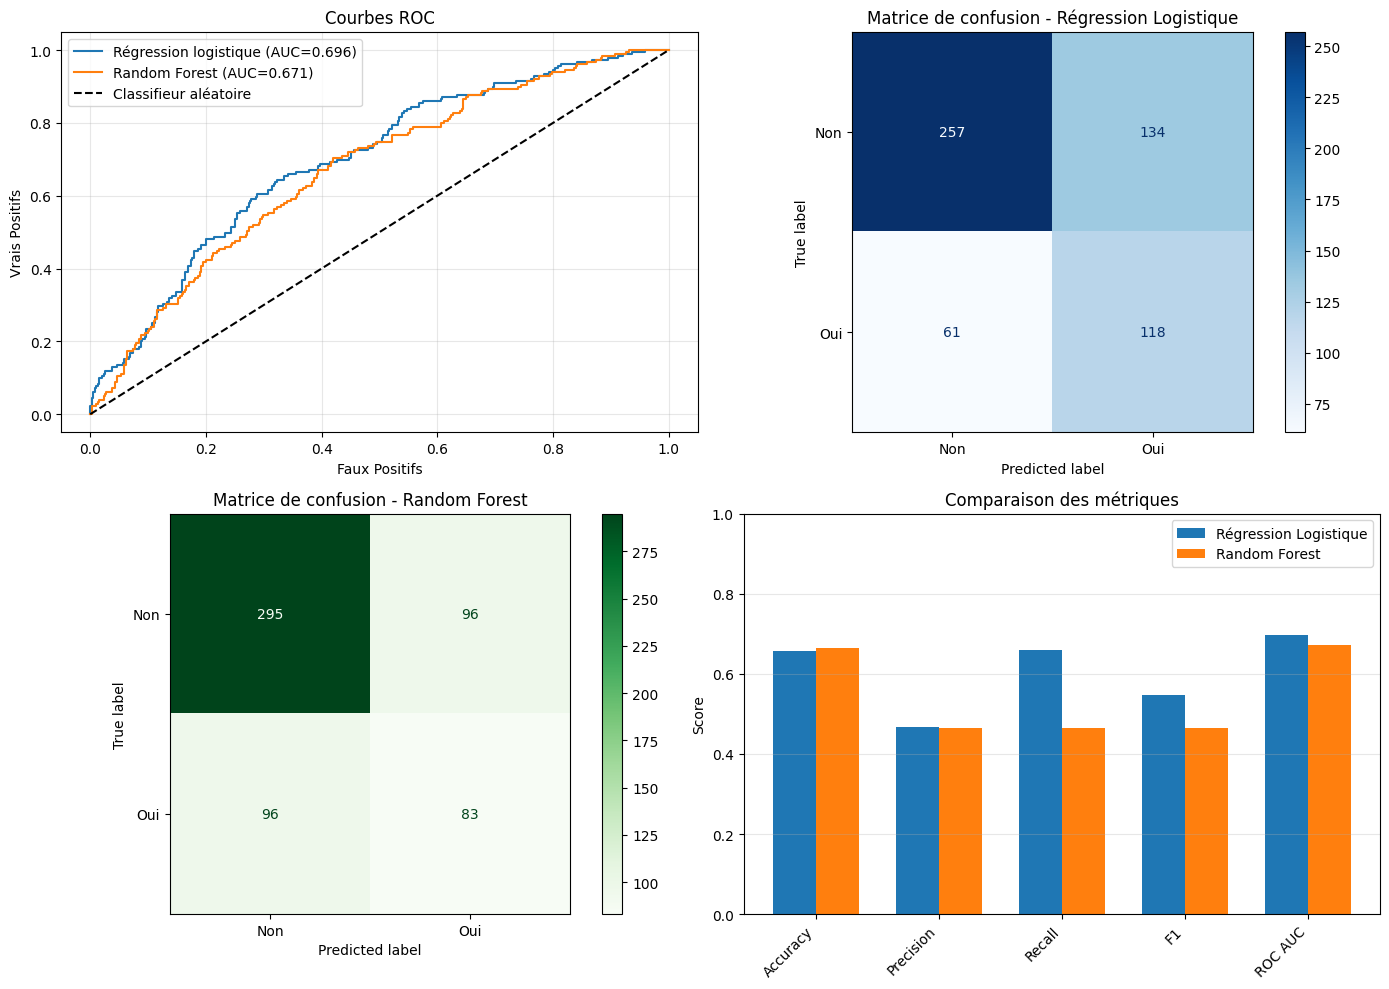

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Courbes ROC
fpr_log, tpr_log, _ = roc_curve(y_test, y_pred_proba_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)

axes[0, 0].plot(fpr_log, tpr_log, label=f'Régression logistique (AUC={roc_auc_score(y_test, y_pred_proba_log):.3f})')
axes[0, 0].plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={roc_auc_score(y_test, y_pred_proba_rf):.3f})')
axes[0, 0].plot([0, 1], [0, 1], 'k--', label='Classifieur aléatoire')
axes[0, 0].set_xlabel('Faux Positifs')
axes[0, 0].set_ylabel('Vrais Positifs')
axes[0, 0].set_title('Courbes ROC')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 2. Matrices de confusion
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_log), display_labels=['Non', 'Oui']).plot(ax=axes[0, 1], cmap='Blues')
axes[0, 1].set_title('Matrice de confusion - Régression Logistique')

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf), display_labels=['Non', 'Oui']).plot(ax=axes[1, 0], cmap='Greens')
axes[1, 0].set_title('Matrice de confusion - Random Forest')

# 3. Comparaison des métriques
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC AUC']
log_scores = [metrics_log[m] for m in metrics_names]
rf_scores = [metrics_rf[m] for m in metrics_names]

x = np.arange(len(metrics_names))
width = 0.35

axes[1, 1].bar(x - width/2, log_scores, width, label='Régression Logistique')
axes[1, 1].bar(x + width/2, rf_scores, width, label='Random Forest')
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_title('Comparaison des métriques')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(metrics_names, rotation=45, ha='right')
axes[1, 1].legend()
axes[1, 1].set_ylim([0, 1])
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## Étape 8 – Analyse de Seuil de Décision

•	Objectif :
Optimiser le seuil de probabilité selon les objectifs métier.


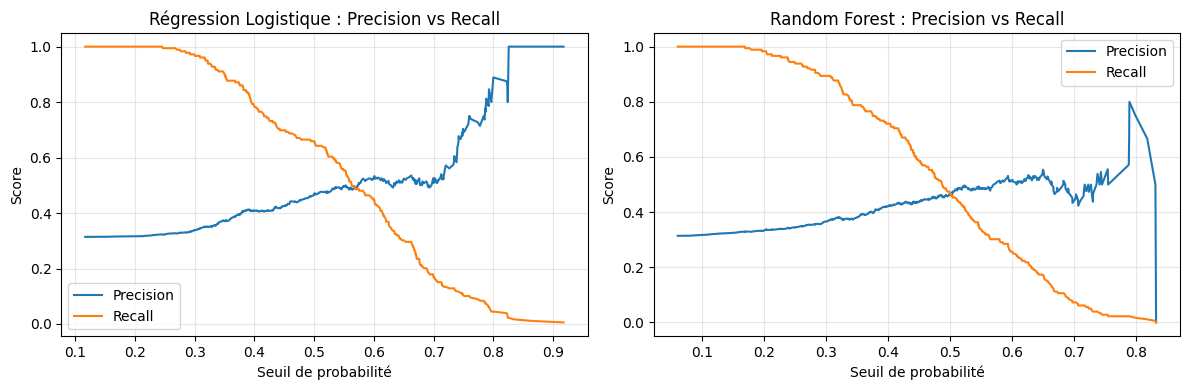


Performances avec seuil = 0.4 (Random Forest) :
Recall : 0.7207
Precision : 0.4216
F1 : 0.5320


In [ ]:
# Courbe Precision-Recall en fonction du seuil
from sklearn.metrics import precision_recall_curve

precision_log, recall_log, thresholds_log = precision_recall_curve(y_test, y_pred_proba_log)
precision_rf, recall_rf, thresholds_rf = precision_recall_curve(y_test, y_pred_proba_rf)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(thresholds_log, precision_log[:-1], label='Precision')
plt.plot(thresholds_log, recall_log[:-1], label='Recall')
plt.xlabel('Seuil de probabilité')
plt.ylabel('Score')
plt.title('Régression Logistique : Precision vs Recall')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(thresholds_rf, precision_rf[:-1], label='Precision')
plt.plot(thresholds_rf, recall_rf[:-1], label='Recall')
plt.xlabel('Seuil de probabilité')
plt.ylabel('Score')
plt.title('Random Forest : Precision vs Recall')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Analyse avec seuil personnalisé
threshold = 0.4  # Exemple : augmenter recall en baissant le seuil

y_pred_rf_custom = (y_pred_proba_rf >= threshold).astype(int)
print(f"\nPerformances avec seuil = {threshold} (Random Forest) :")
print(f"Recall : {recall_score(y_test, y_pred_rf_custom):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_rf_custom):.4f}")
print(f"F1 : {f1_score(y_test, y_pred_rf_custom):.4f}")


## Étape 9 – Recommandation et Déploiement

### Critères de Sélection

| Critère | Régression Logistique | Random Forest |
|---------|----------------------|---------------|
| **Interprétabilité** | ✓ Excellente (coefficients simples) | ✗ Complexe (boîte noire) |
| **Performance** | ✗ Généralement inférieure | ✓ Généralement supérieure |
| **Robustesse** | ✓ Robuste, moins d'overfitting | ✗ Risque d'overfitting |
| **Interactions non-linéaires** | ✗ Non détectées | ✓ Bien capturées |
| **Déploiement** | ✓ Léger et rapide | ✗ Volumineux et lent |


##	Recommandation Finale

1. **Si Recall est critique** (minimiser les faux négatifs) → **Random Forest**
   - Réduire le seuil de décision si nécessaire
   - Accepter plus de faux positifs
   - Utiliser SHAP ou LIME pour expliquer les décisions

2. **Si Precision est critique** (limiter les faux positifs) → **Régression Logistique**
   - Augmenter le seuil de décision
   - Modèle simpler et plus justifiable auprès du métier

3. **Approche recommandée : Ensemble (Voting Classifier)**
   ```python
   from sklearn.ensemble import VotingClassifier
   
   voting_model = VotingClassifier(
       estimators=[('log', log_model), ('rf', rf_model)],
       voting='soft'  # Fait une moyennes des probabilités
   )
   voting_model.fit(X_train, y_train)
   ```


### Étapes de Déploiement
1. Valider le modèle sur données de validation temporelles (si possible)
2. Mettre en place le monitoring (drift détection, performance)
3. Définir le seuil opérationnel avec le métier
4. Créer des pipelines d'inférence avec versioning
5. Documenter les décisions et limitations

---

## Points d'Améliorations Futurs

1. **Feature Engineering** : Créer des variables d'interaction (ex: visites × revenu)
2. **Gestion du déséquilibre** : SMOTE, class_weight, threshold optimization
3. **Validation croisée** : Utiliser cross_val_score() pour évaluer la stabilité
4. **Tuning d'hyperparamètres** : GridSearchCV ou RandomizedSearchCV
5. **Explainabilité** : SHAP values, permutation importance
6. **Tests A/B** : Comparer le modèle en production avec une version baseline

---

## Annexe : Checklist "Qualité"

- [ ] Vérification des valeurs manquantes et stratégie d'imputation documentée
- [ ] Pas de fuite d'information (data leakage)
- [ ] Stratification appliquée lors du split train/test
- [ ] Normalisation/standardisation si pertinente
- [ ] Évaluation avec métriques adaptées au problème métier
- [ ] Comparaison avec baseline (dummy model)
- [ ] Analyse du déséquilibre des classes
- [ ] Visualisations exploratoires documentées
- [ ] Reproductibilité assurée (random_state)
- [ ] Code commenté et structuré